# Library

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow import keras

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

# Data Set

In [ ]:
Fashion_data = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
Fashion_data

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

# Performance matrics

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Splitting raw data

In [ ]:
(x_train_sp, y_train_sp), (x_test_sp, y_test_sp) = Fashion_data

In [ ]:
x_train_sp.shape

(60000, 28, 28)

In [ ]:
x_test_sp.shape

(10000, 28, 28)

In [ ]:
y_train_sp.shape

(60000,)

In [ ]:
y_test_sp.shape

(10000,)

# Fashion Items Label

In [ ]:
items_name = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
items_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
# Reshaping Data
x_train_sp = x_train_sp.reshape((60000, 28, 28, 1))
x_test_sp = x_test_sp.reshape((10000, 28, 28, 1))

In [ ]:
x_train_sp.shape

(60000, 28, 28, 1)

In [ ]:
x_test_sp.shape

(10000, 28, 28, 1)

In [ ]:
# Normalize data
x_train_norm = x_train_sp / 255.0
x_test_norm = x_test_sp / 255.0

In [ ]:
# Data Splitting for Training, Testing and Validation
x_validate, x_train = x_train_norm[:5000], x_train_norm[5000:]
y_validate, y_train = y_train_sp[:5000], y_train_sp[5000:]
x_test = x_test_norm

In [ ]:
y_train.shape

(55000,)

In [ ]:

# Random Seed
tf.random.set_seed(42)

# Model Architecture
model = keras.models.Sequential()

# Building Model
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1,
                              padding='valid', activation='relu', input_shape=(28, 28, 1)))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

# Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     1,622,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,130 (6.31 MB)

 Trainable params: 1,654,130 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.7233 - loss: 0.8038 - val_accuracy: 0.7328 - val_loss: 0.7340
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.8053 - loss: 0.5338 - val_accuracy: 0.7870 - val_loss: 0.5911
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8269 - loss: 0.4767 - val_accuracy: 0.8120 - val_loss: 0.5265
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.8403 - loss: 0.4406 - val_accuracy: 0.8292 - val_loss: 0.4823
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.8506 - loss: 0.4141 - val_accuracy: 0.8388 - val_loss: 0.4489


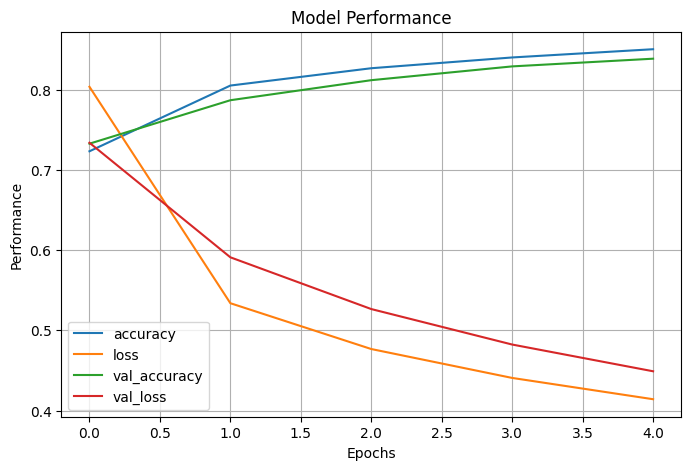

In [ ]:
# Compiling the model
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])

# Fitting Values to Model
model_fit = model.fit(x_train, y_train, epochs=5, batch_size=64,
                      validation_data=(x_validate, y_validate))

# Model Performance Visualization
pd.DataFrame(model_fit.history).plot(figsize=(8, 5))
plt.title('Model Performance')
plt.xlabel('Epochs')
plt.ylabel('Performance')
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8136 - loss: 0.5026
Model Evaluation Score : [0.5025792717933655, 0.8136000037193298]
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
y_pred output : [9 2 1 ... 8 1 5]
Predicted Class :  [9 2 1]
Predicted Class in Labels :  ['Ankle boot' 'Pullover' 'Trouser']


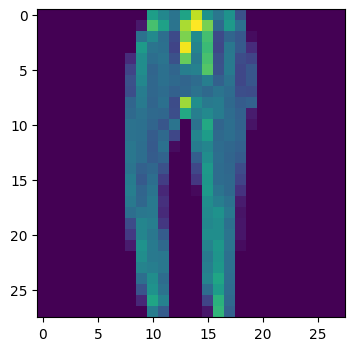

Confusion Matrix : 
 [[521   0  56  39  20   2 348   0  14   0]
 [  0 952   3  27  10   0   6   0   2   0]
 [  3   1 735   7 228   1  21   0   4   0]
 [  2  10  30 782 107   1  63   0   5   0]
 [  0   0  64   6 908   0  18   0   4   0]
 [  0   0   0   1   0 889   0  74   4  32]
 [ 34   0 166  20 247   0 511   0  22   0]
 [  0   0   0   0   0  16   0 949   1  34]
 [  0   1  29   5  13   2   6   6 938   0]
 [  0   0   0   0   0   3   0  45   1 951]]
Accuracy Score :  0.8136
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.52      0.67      1000
           1       0.99      0.95      0.97      1000
           2       0.68      0.73      0.71      1000
           3       0.88      0.78      0.83      1000
           4       0.59      0.91      0.72      1000
           5       0.97      0.89      0.93      1000
           6       0.53      0.51      0.52      1000
           7       0.88      0.95      0.92      1000
          

In [ ]:
# Model Evaluation
score = model.evaluate(x_test, y_test_sp)
print('Model Evaluation Score :', score)

# Prediction & Class Output
y_pred = np.argmax(model.predict(x_test), axis=-1)
print('y_pred output :', y_pred)

# Class & Labels of initial 3 data
print('Predicted Class : ', y_pred[:3])
print('Predicted Class in Labels : ', np.array(items_name)[y_pred[:3]])

# Predicted Output Visualization
plt.figure(figsize=(6, 4))
plt.imshow(x_test[80].reshape((28, 28)))
plt.show()

# Performance Metrics
# Confusion Matrix
print('Confusion Matrix : \n', confusion_matrix(y_test_sp, y_pred))

# Accuracy Score
print('Accuracy Score : ', accuracy_score(y_test_sp, y_pred))

# Classification Report
print('Classification Report : \n', classification_report(y_test_sp, y_pred))